# Daisyworld: пространственное состояние

Базовый опыт: сетка 30×30, два вида, светимость 1.0, seed 165.

## Окружение и модель

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("experiments.jl"))

savehistory (generic function with 1 method)

## Последовательная эволюция

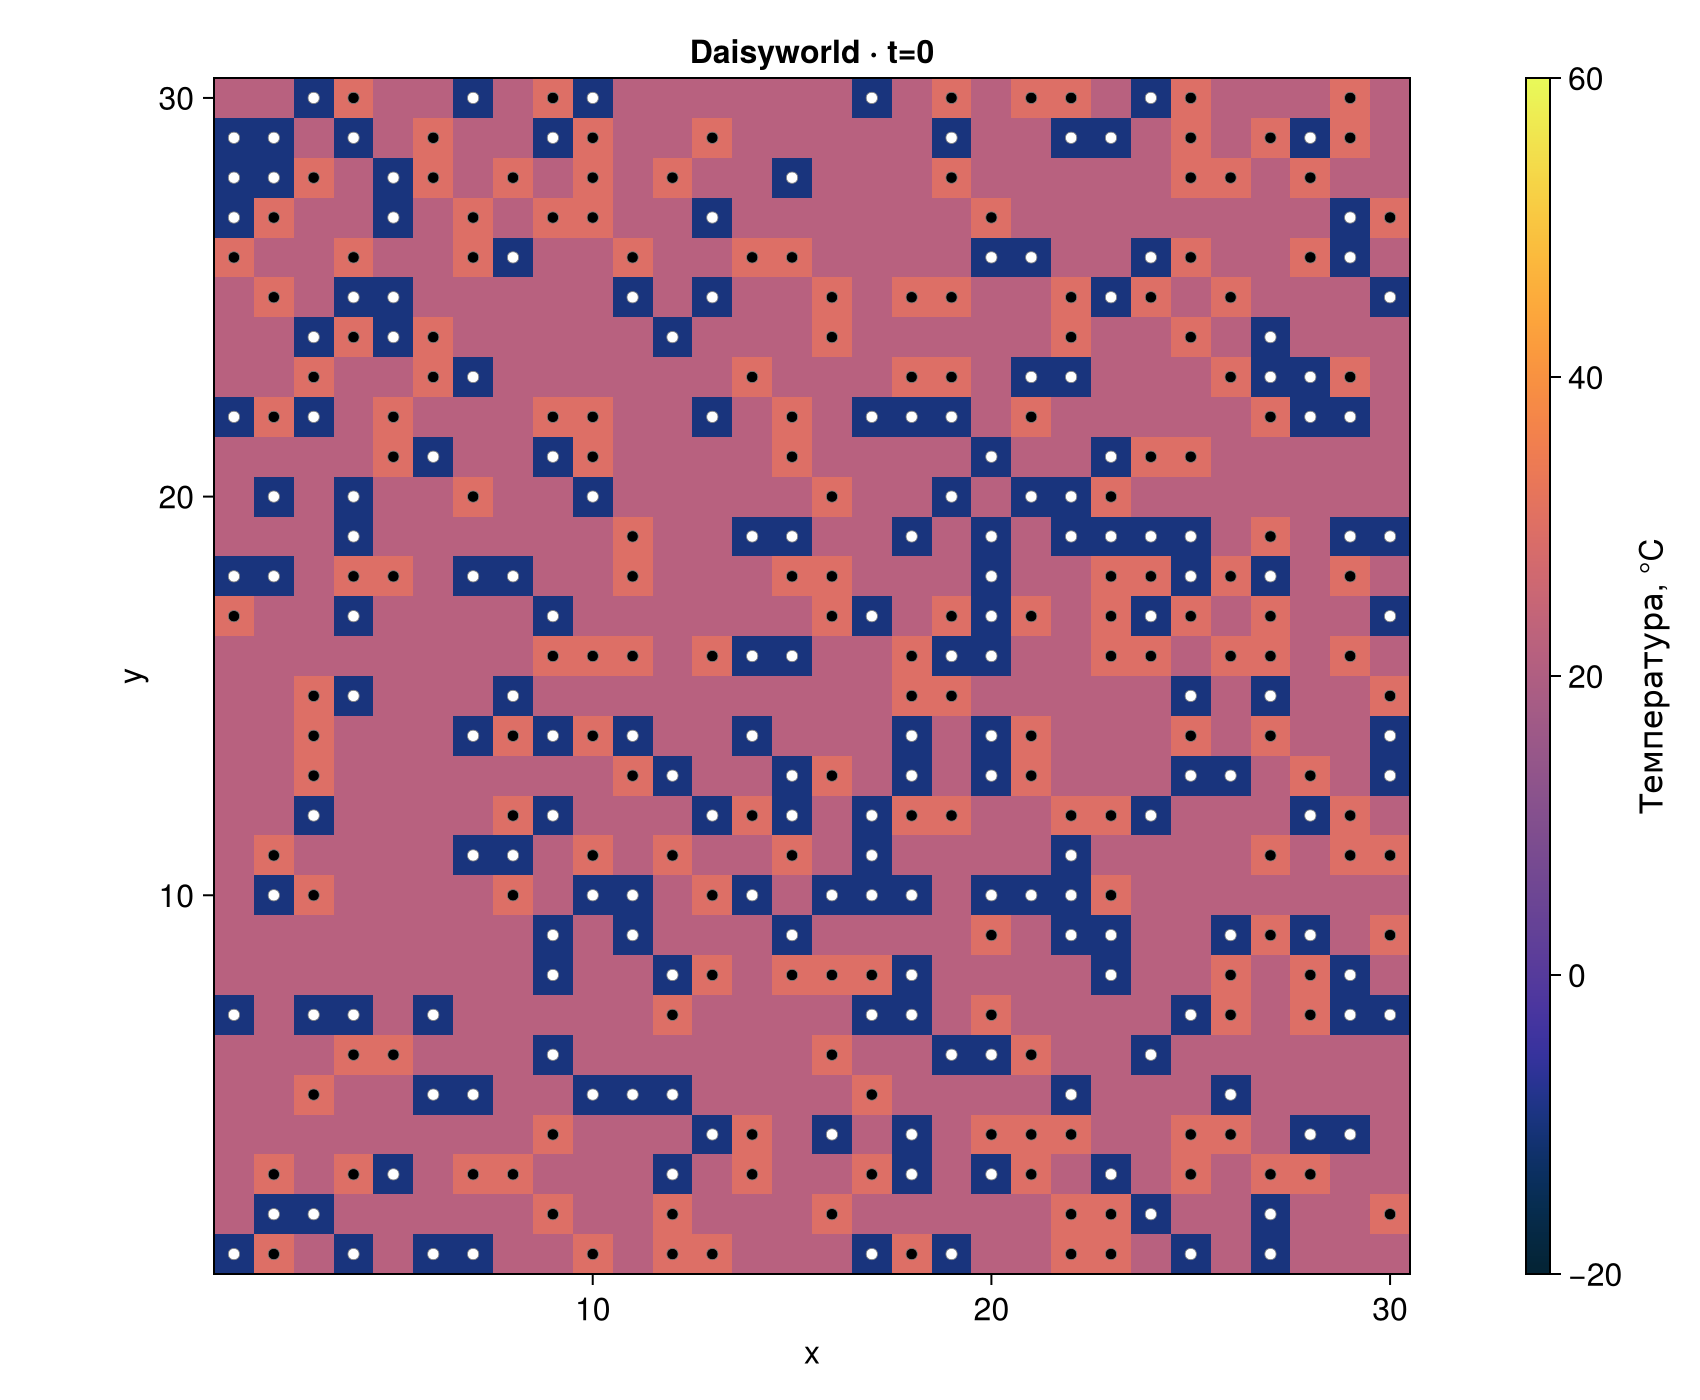

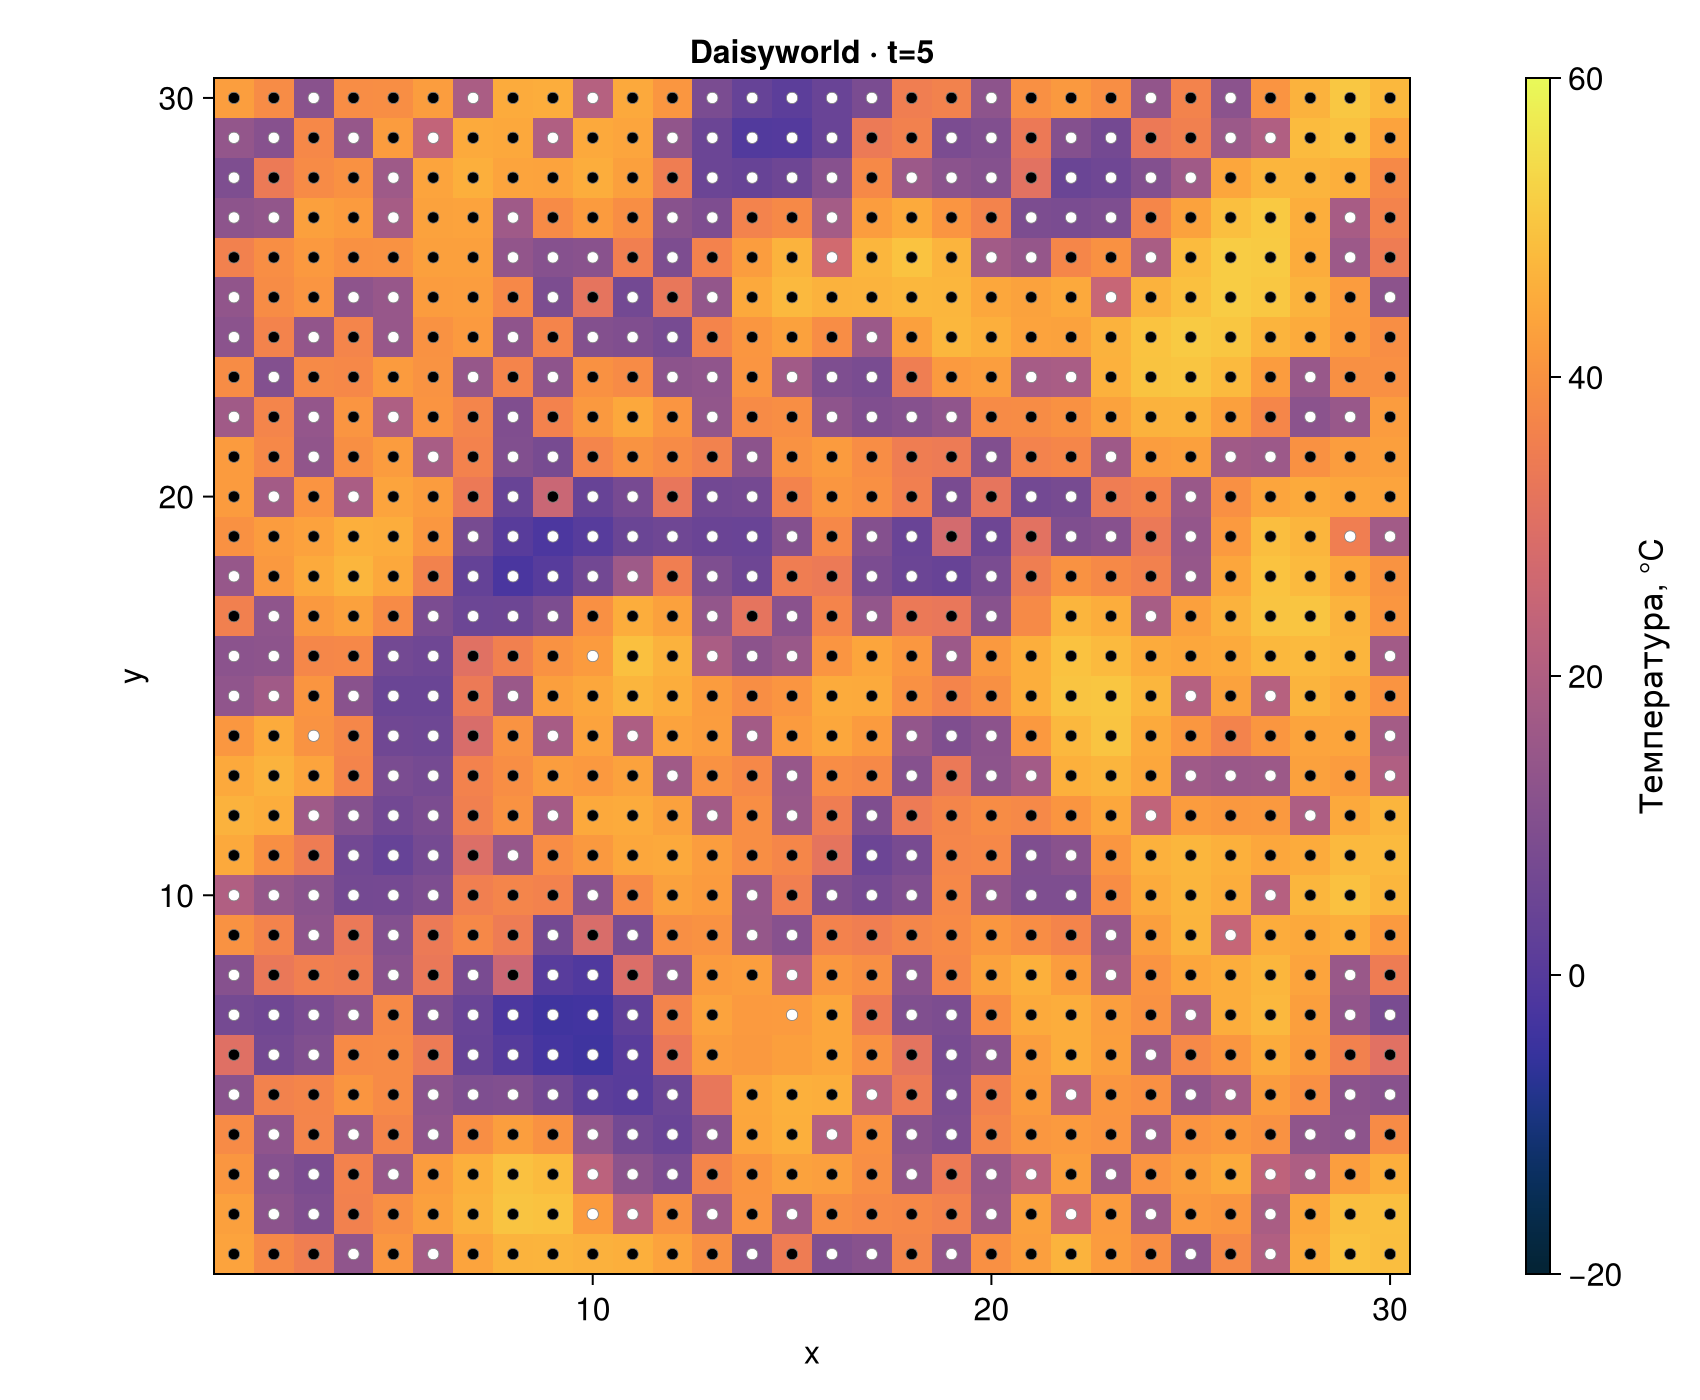

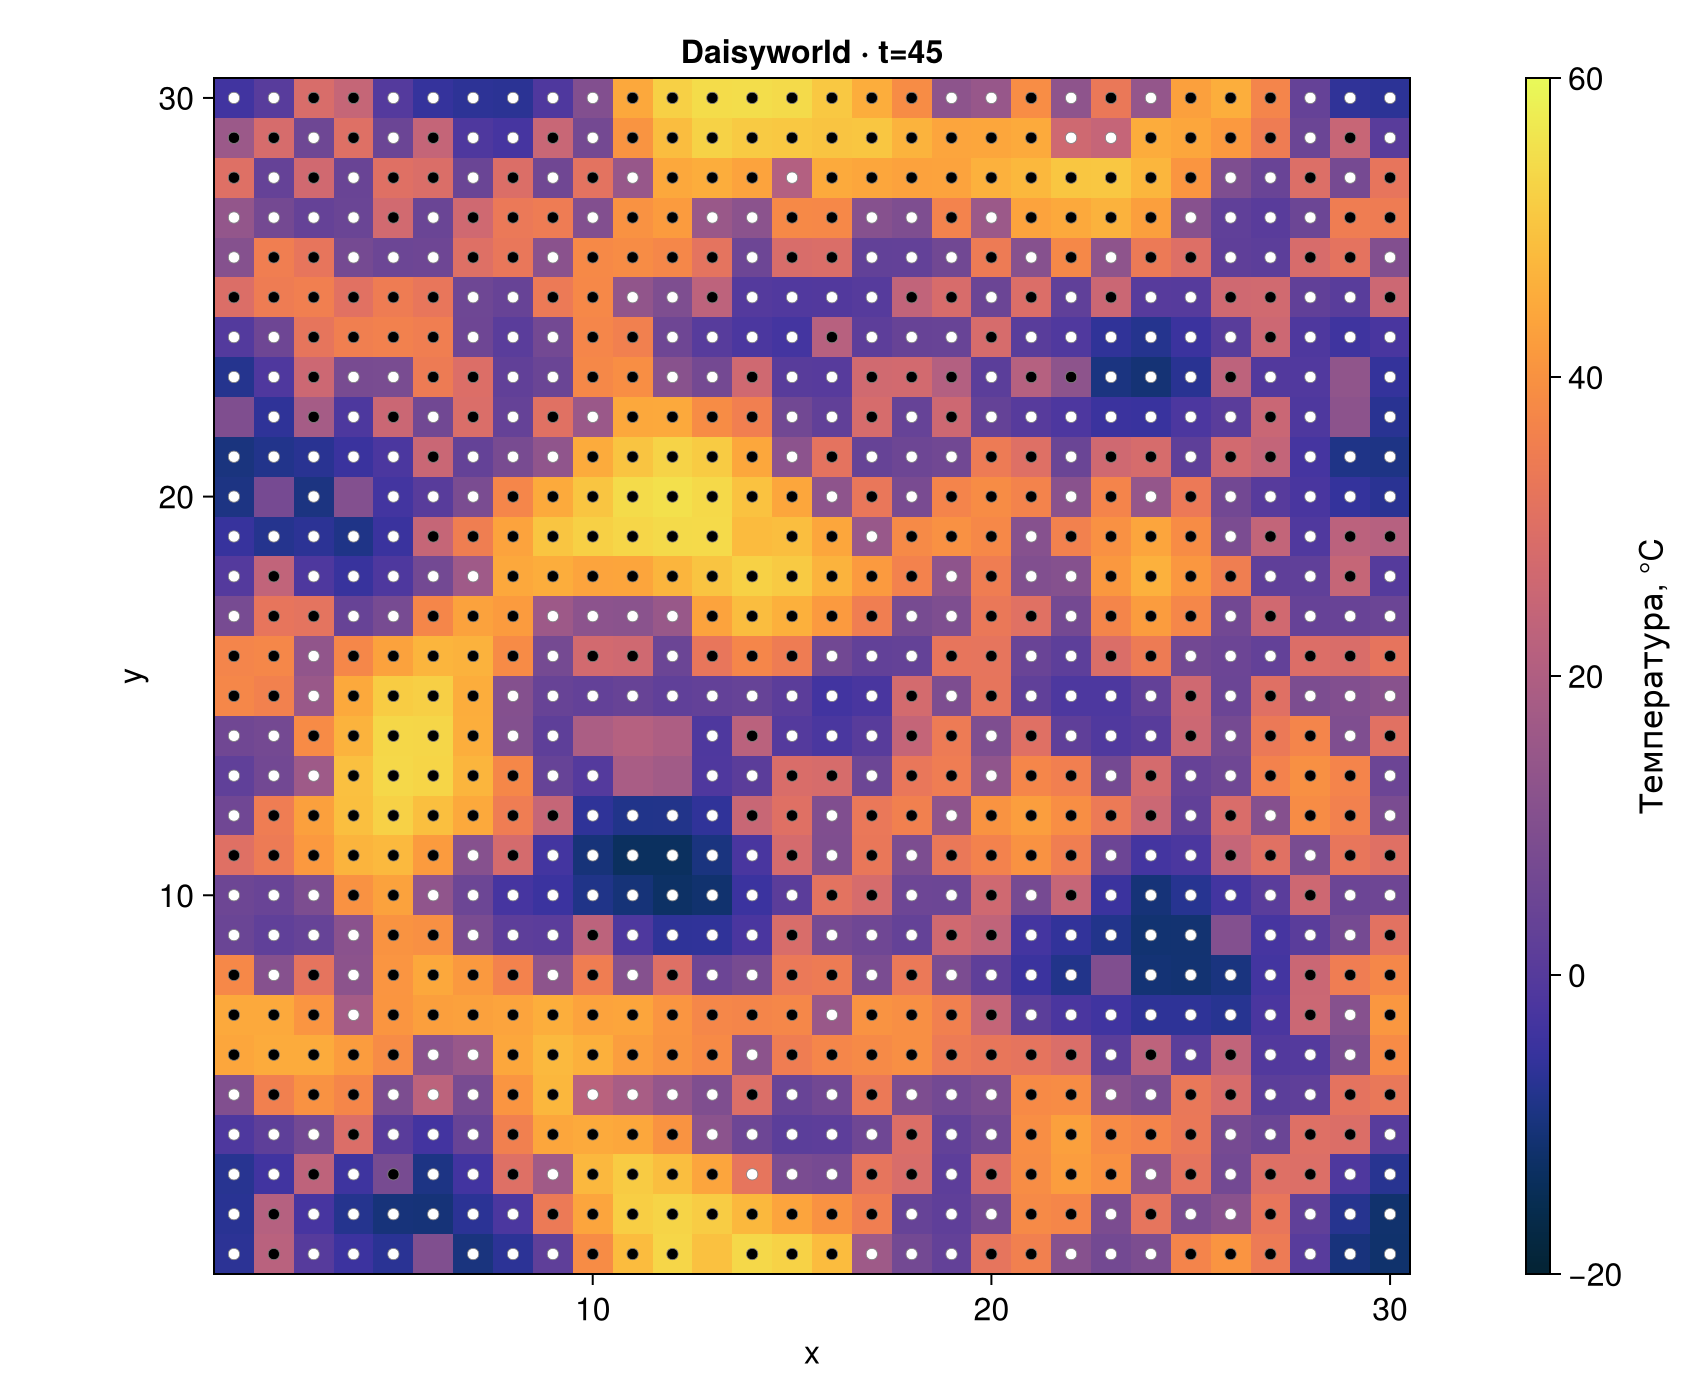

In [2]:
model = daisyworld()
snapshots = DataFrame[]
for (i, target) in enumerate((0, 5, 45))
    advance!(model, target - model.tick)
    push!(snapshots, DataFrame([measure(model)]))
    figure = snapshot(model)
    save(imagefile(lpad(i, 2, '0') * "-plot.png"), figure)
    display(figure)
end

## Сохранённые измерения

In [3]:
summary = reduce(vcat, snapshots)
CSV.write(datafile("daisyworld", "snapshots.csv"), summary)
summary

Row,time,black,white,temperature,luminosity,albedo
,Int64,Int64,Int64,Float64,Float64,Float64
1,0,180,180,16.9135,1.0,0.44
2,5,563,332,30.3647,1.0,0.435278
3,45,450,435,20.1288,1.0,0.494167
